# Direction E - Xử lý dữ liệu lệch lớp cho dự đoán kháng kháng sinh Salmonella

1. Dùng ma trận gen phụ đầy đủ làm nguồn đặc trưng chính.
2. Chọn đặc trưng chỉ trên tập huấn luyện để tránh rò rỉ thông tin.
3. So sánh nhiều cách xử lý dữ liệu lệch lớp.
4. Tập trung vào khả năng phát hiện mẫu kháng thuốc, không chỉ nhìn độ chính xác chung.

In [1]:
# Cấu hình chung
import os
from pathlib import Path

BASE_DIR = Path("/content/salmonella_direction_E")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
OUT_DIR = BASE_DIR / "outputs"
EXTRACT_DIR = BASE_DIR / "extracted"

BASE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

N_REPEATS = 10
TEST_SIZE = 0.2
K_FEATURES = 200
RANDOM_SEEDS = list(range(N_REPEATS))

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)
print("Không dùng Google Drive.")

BASE_DIR: /content/salmonella_direction_E
OUT_DIR: /content/salmonella_direction_E/outputs
Không dùng Google Drive.


In [ ]:

import subprocess
import os
from pathlib import Path

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git {REPO_DIR}
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("Kiểm tra thư mục data/csv:")
!find {REPO_DIR}/data/csv -maxdepth 2 -type f | head -30

Cloning into '/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 13.29 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Kiểm tra thư mục data/csv:
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/data/csv/CHL/gene.csv
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/data/csv/CHL/CHL_label.csv
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/data/csv/AMP/gene.csv
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/data/csv/AMP/AMP_label.csv
/content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/data/csv/FOX/gene.csv
/content/salmonella_direction_E/An

In [ ]:

!apt-get update -qq
!apt-get install -y unrar > /dev/null
print("Đã cài unrar.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Đã cài unrar.


In [ ]:
# Import thư viện
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.utils import resample

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    print("Không import được XGBoost:", e)
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [5]:
# Hàm đọc nhãn theo từng thuốc
def load_drug_label(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    label_path = drug_dir / f"{drug}_label.csv"
    y_df = pd.read_csv(label_path)

    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]
    else:
        possible_cols = [c for c in y_df.columns if "label" in c.lower() or drug.lower() in c.lower()]
        y = y_df[possible_cols[0]] if possible_cols else y_df.iloc[:, -1]

    y = y.replace({"S": 0, "I": 0, "R": 1, "s": 0, "i": 0, "r": 1})
    y = pd.to_numeric(y, errors="coerce")
    y.index = [f"sample_{i}" for i in range(len(y))]
    y = y.astype("Int64")
    return y

# Thống kê nhãn
label_summary = []
labels_by_drug = {}
for drug in DRUGS:
    y = load_drug_label(drug).dropna().astype(int)
    labels_by_drug[drug] = y
    label_summary.append({
        "drug": drug,
        "n_samples": len(y),
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y == 0).sum()),
        "resistant_rate": float(y.mean()),
    })

label_summary_df = pd.DataFrame(label_summary)
display(label_summary_df)
label_summary_df.to_csv(OUT_DIR / "direction_E_label_summary.csv", index=False)

,drug,n_samples,n_resistant,n_non_resistant,resistant_rate
0,AMP,1167,199,968,0.170523
1,AUG,1167,139,1028,0.119109
2,AXO,1167,71,1096,0.060840
3,CHL,1167,126,1041,0.107969
4,FOX,1167,71,1096,0.060840


In [6]:
# Đọc ma trận gen phụ đầy đủ
rar_path = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"
extract_accessory_dir = EXTRACT_DIR / "accessory_gene"
extract_accessory_dir.mkdir(parents=True, exist_ok=True)

existing_csv = list(extract_accessory_dir.rglob("*.csv"))
if not existing_csv:
    print("Đang giải nén:", rar_path)
    !unrar x -o+ "{rar_path}" "{extract_accessory_dir}/" > /dev/null
else:
    print("Đã có file csv sau giải nén.")

csv_files = list(extract_accessory_dir.rglob("*.csv"))
print("CSV files:", csv_files[:5])
if not csv_files:
    raise FileNotFoundError("Không tìm thấy file csv của ma trận gen phụ.")

accessory_csv = max(csv_files, key=lambda p: p.stat().st_size)
print("Đọc ma trận gen phụ:", accessory_csv)

X_accessory_raw = pd.read_csv(accessory_csv)
print("Raw shape:", X_accessory_raw.shape)
display(X_accessory_raw.head(2))

Đang giải nén: /content/salmonella_direction_E/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
CSV files: [PosixPath('/content/salmonella_direction_E/extracted/accessory_gene/accessory gene existence matrix.csv')]
Đọc ma trận gen phụ: /content/salmonella_direction_E/extracted/accessory_gene/accessory gene existence matrix.csv
Raw shape: (1167, 18126)


,Unnamed: 0,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL,nsrR,CE641_06520,priB,atpB,C2K48_18010,glmU,GPC98_001636,pepD,KDM75_001078,mnmG,GPQ64_004095,recG,pspE,rnr,rbsC,CEZ51_03995,GPA53_001343,K6M88_000542,ulaC,GV878_10160,radC,pyrL,GTT10_000474,rpmG,tyrR,mntS,ogt,GNM13_02880,EGD39_01585,bsmA,guaB,spoT,GXF62_03920,group_19145,rbsD,yciH,lpcA,C3Z62_00515,pyrI,cpdB,DX213_00020,pstB,CCW16_04575,DVE01_20805,CUW18_04075,narI,H9B23_004112,FE071_05445,GXL71_02575,fadE,msrA,CFA88_15545,DA847_10905,DA847_15700,C2W72_21305,nrdG,cycA,mdtL,GSC17_002079,GUE18_000823,K3989_003569,NDU77_001820,blc,K6L68_004380,HBY45_003073,DXW66_13920,LH860_000156,C1K45_07960,GSD82_002385,B9U48_07425,EAU51_19150,INC55_002963,C9B03_13430,I3F91_003850,kdpE,GZB80_001698,KDM75_001152,spiC,sipA,CJG77_01680,H3B95_000294,hrpB,CFC30_001448,C3011_17690,KYI33_003816,dedD,hutH,GVB84_004100,mlaE,LLA84_004136,E5649_21215,...,EWW67_24190,EWW67_24195,CJ664_24880,CFC17_24285,CFC17_24290,CJ664_24885,CJ664_24890,FBB63_23745,CFC17_24295,CJ664_24900,CFC17_24305,CJ664_24905,CFC17_24310,CJ664_24910,CFC17_24315,FBB63_23050,CJ664_24925,CFC17_24330,CFC17_24335,CJ664_24930,CJ664_24935,CFC17_24340,CJ664_24945,CFC17_24350,CFC17_24355,group_9764,CFC17_24360,CJ664_24955,CJ664_24965,GXG37_24035,CFC17_24370,CJ664_24975,CFC17_24380,CJ664_24985,CFC17_24390,CJ664_24845,CFC17_24250,E3I96_22805,E3K79_09395,E3K79_09400,E3K79_09405,E3K79_09530,E3K79_17705,M8W61_004957,GY309_005110,GVB88_004868,K1191_004978,K1191_004979,GY309_005111,M8W61_004958,CIH76_24580,CFE76_24980,GY309_005113,CIH76_24590,GY309_005114,GVB88_004872,K1191_004981,M8W61_004960,E3K79_24685,E3K79_24675,aac(3)-IId,group_9830,group_9831,group_9832,group_9834,group_9835,GVB81_004985,GXR61_005002,E6U56_24000,GVC77_004899,CEW36_25740,GWJ30_24850,E5721_03835,E5721_03840,GSC72_004744,E5721_03890,E5721_04000,E6B36_14780,E3K74_23715,E3V06_02760,K3K99_004871,IQT32_004913,NJA97_004922,DQ665_27120,group_9873,IYQ21_004865,K3K99_004875,DSC76_25825,I3040_005055,CP786_24040,D5S55_04420,EOH01_20505,EOH01_23295,EOH01_24105,CFJ60_24800,DCH97_24375,CIX89_24825,D6I09_24665,D6I09_24690,D6I09_24695
0,GCA_003737005.1_PDT000397393.1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GCA_003744485.1_PDT000397419.1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# Làm sạch ma trận gen phụ
def clean_feature_matrix(df, expected_n=1167):
    X = df.copy()

    # Nếu có cột mã mẫu dạng chữ, bỏ khỏi feature
    non_numeric_cols = []
    for col in list(X.columns):
        if X[col].dtype == "object":
            converted = pd.to_numeric(X[col], errors="coerce")
            if converted.notna().mean() > 0.95:
                X[col] = converted.fillna(0)
            else:
                non_numeric_cols.append(col)
    if non_numeric_cols:
        print("Bỏ cột không phải số:", non_numeric_cols[:10], "..." if len(non_numeric_cols) > 10 else "")
        X = X.drop(columns=non_numeric_cols)

    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

    if X.shape[0] == expected_n:
        X.index = [f"sample_{i}" for i in range(expected_n)]
    else:
        print("Cảnh báo: số dòng khác expected_n:", X.shape[0])

    X = (X > 0).astype(np.int8)

    nunique = X.nunique(axis=0)
    variable_cols = nunique[nunique > 1].index
    X = X[variable_cols]
    return X

X_accessory = clean_feature_matrix(X_accessory_raw, expected_n=1167)
print("Accessory cleaned shape:", X_accessory.shape)
display(X_accessory.iloc[:3, :8])

Bỏ cột không phải số: ['Unnamed: 0'] 
Accessory cleaned shape: (1167, 18125)


,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL
sample_0,1,1,1,1,1,1,1,1
sample_1,1,1,1,1,1,1,1,1
sample_2,1,1,1,1,1,1,1,1


In [8]:
# Hàm tính metric
def safe_metrics(y_true, y_pred, y_prob):
    out = {}
    out["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred, zero_division=0)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)
    try:
        out["auroc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["auroc"] = np.nan
    try:
        out["auprc"] = average_precision_score(y_true, y_prob)
    except Exception:
        out["auprc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out["tn"] = int(tn)
    out["fp"] = int(fp)
    out["fn"] = int(fn)
    out["tp"] = int(tp)
    out["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return out

def choose_threshold_on_validation(y_val, prob_val, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_thr = 0.5
    best_score = -1

    for thr in thresholds:
        pred = (prob_val >= thr).astype(int)
        if metric == "f1":
            score = f1_score(y_val, pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_val, pred)
        elif metric == "recall":
            tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            score = recall if specificity >= 0.70 else recall * specificity
        else:
            score = f1_score(y_val, pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr), float(best_score)

def oversample_minority(X_train, y_train, random_state=0):
    df = X_train.copy()
    df["_label"] = y_train.values

    df_major = df[df["_label"] == 0]
    df_minor = df[df["_label"] == 1]

    if len(df_minor) == 0 or len(df_major) == 0:
        return X_train, y_train

    df_minor_up = resample(
        df_minor,
        replace=True,
        n_samples=len(df_major),
        random_state=random_state,
    )
    df_bal = pd.concat([df_major, df_minor_up], axis=0).sample(frac=1, random_state=random_state)
    y_bal = df_bal["_label"].astype(int)
    X_bal = df_bal.drop(columns=["_label"])
    return X_bal, y_bal

In [9]:
# Hàm đánh giá một thuốc với nhiều chiến lược xử lý lệch lớp
def evaluate_imbalance_for_drug(drug, X_full, k_features=200, n_repeats=10):
    y = labels_by_drug[drug].dropna().astype(int)
    common_idx = X_full.index.intersection(y.index)
    X = X_full.loc[common_idx]
    y = y.loc[common_idx]

    rows = []
    selected_counter = Counter()

    for seed in range(n_repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y,
        )

        k = min(k_features, X_train.shape[1])
        selector = SelectKBest(score_func=chi2, k=k)
        X_train_sel = selector.fit_transform(X_train, y_train)
        X_test_sel = selector.transform(X_test)
        selected_features = X_train.columns[selector.get_support()].tolist()
        selected_counter.update(selected_features)

        X_train_sel = pd.DataFrame(X_train_sel, index=X_train.index, columns=selected_features)
        X_test_sel = pd.DataFrame(X_test_sel, index=X_test.index, columns=selected_features)

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_sel, y_train,
            test_size=0.25,
            random_state=seed,
            stratify=y_train,
        )

        strategies = []

        strategies.append({
            "strategy": "LR_plain_threshold_0.5",
            "model": LogisticRegression(max_iter=5000, solver="liblinear"),
            "train_X": X_train_sel,
            "train_y": y_train,
            "threshold_mode": "fixed",
            "threshold": 0.5,
        })

        strategies.append({
            "strategy": "LR_class_weight_balanced_threshold_0.5",
            "model": LogisticRegression(max_iter=5000, solver="liblinear", class_weight="balanced"),
            "train_X": X_train_sel,
            "train_y": y_train,
            "threshold_mode": "fixed",
            "threshold": 0.5,
        })

        strategies.append({
            "strategy": "LR_balanced_threshold_tuned_F1",
            "model": LogisticRegression(max_iter=5000, solver="liblinear", class_weight="balanced"),
            "train_X": X_tr,
            "train_y": y_tr,
            "val_X": X_val,
            "val_y": y_val,
            "threshold_mode": "tune_f1",
        })

        X_over, y_over = oversample_minority(X_train_sel, y_train, random_state=seed)
        strategies.append({
            "strategy": "LR_random_oversampling_threshold_0.5",
            "model": LogisticRegression(max_iter=5000, solver="liblinear"),
            "train_X": X_over,
            "train_y": y_over,
            "threshold_mode": "fixed",
            "threshold": 0.5,
        })

        if XGBOOST_AVAILABLE:
            neg = int((y_train == 0).sum())
            pos = int((y_train == 1).sum())
            scale_pos_weight = neg / max(pos, 1)
            strategies.append({
                "strategy": "XGBoost_scale_pos_weight",
                "model": XGBClassifier(
                    n_estimators=250,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="logloss",
                    random_state=seed,
                    n_jobs=2,
                    scale_pos_weight=scale_pos_weight,
                ),
                "train_X": X_train_sel,
                "train_y": y_train,
                "threshold_mode": "fixed",
                "threshold": 0.5,
            })

        for item in strategies:
            model = item["model"]
            model.fit(item["train_X"], item["train_y"])

            threshold = item.get("threshold", 0.5)
            threshold_score = np.nan

            if item["threshold_mode"] == "tune_f1":
                val_prob = model.predict_proba(item["val_X"])[:, 1]
                threshold, threshold_score = choose_threshold_on_validation(item["val_y"], val_prob, metric="f1")

            prob = model.predict_proba(X_test_sel)[:, 1]
            pred = (prob >= threshold).astype(int)
            m = safe_metrics(y_test, pred, prob)
            m.update({
                "drug": drug,
                "repeat": seed,
                "strategy": item["strategy"],
                "k_features": k,
                "threshold": threshold,
                "threshold_validation_score": threshold_score,
                "n_train": len(y_train),
                "n_test": len(y_test),
                "train_resistant": int(y_train.sum()),
                "test_resistant": int(y_test.sum()),
            })
            rows.append(m)

    return pd.DataFrame(rows), selected_counter

In [10]:
# Chạy Direction E
all_rows = []
selected_by_drug = {}

for drug in DRUGS:
    print("=" * 80)
    print("Đang chạy drug:", drug)
    print("=" * 80)
    df_drug, counter = evaluate_imbalance_for_drug(
        drug=drug,
        X_full=X_accessory,
        k_features=K_FEATURES,
        n_repeats=N_REPEATS,
    )
    all_rows.append(df_drug)
    selected_by_drug[drug] = counter
    display(df_drug.groupby("strategy")[["balanced_accuracy", "precision", "recall", "f1", "auprc"]].mean().sort_values("f1", ascending=False))

results = pd.concat(all_rows, ignore_index=True)
results.to_csv(OUT_DIR / "direction_E_all_repeat_results.csv", index=False)
print("Done. Results shape:", results.shape)

Đang chạy drug: AMP


,balanced_accuracy,precision,recall,f1,auprc
strategy,,,,,
XGBoost_scale_pos_weight,0.911418,0.889302,0.8450,0.866058,0.895171
LR_plain_threshold_0.5,0.891572,0.934292,0.7950,0.857937,0.884809
LR_random_oversampling_threshold_0.5,0.903325,0.861360,0.8350,0.847240,0.880656
LR_balanced_threshold_tuned_F1,0.898621,0.874132,0.8225,0.846083,0.882534
LR_class_weight_balanced_threshold_0.5,0.900825,0.860016,0.8300,0.844079,0.880975


Đang chạy drug: AUG


,balanced_accuracy,precision,recall,f1,auprc
strategy,,,,,
LR_class_weight_balanced_threshold_0.5,0.974289,0.915454,0.960714,0.937252,0.940041
LR_random_oversampling_threshold_0.5,0.973804,0.909647,0.960714,0.934096,0.942391
XGBoost_scale_pos_weight,0.968447,0.908722,0.950000,0.928467,0.941711
LR_plain_threshold_0.5,0.957160,0.922356,0.925000,0.923063,0.943754
LR_balanced_threshold_tuned_F1,0.959518,0.909231,0.932143,0.918817,0.934439


Đang chạy drug: AXO


...

Đang chạy drug: CHL


,balanced_accuracy,precision,recall,f1,auprc
strategy,,,,,
LR_plain_threshold_0.5,0.901282,0.987138,0.804,0.882144,0.910195
XGBoost_scale_pos_weight,0.924019,0.900173,0.860,0.876678,0.887707
LR_class_weight_balanced_threshold_0.5,0.925301,0.892404,0.864,0.873941,0.906683
LR_balanced_threshold_tuned_F1,0.908411,0.939777,0.824,0.873381,0.903637
LR_random_oversampling_threshold_0.5,0.921780,0.900853,0.856,0.872938,0.906460


Đang chạy drug: FOX


,balanced_accuracy,precision,recall,f1,auprc
strategy,,,,,
LR_class_weight_balanced_threshold_0.5,0.945292,0.962637,0.892857,0.925600,0.909444
LR_random_oversampling_threshold_0.5,0.945065,0.957381,0.892857,0.922604,0.910275
LR_plain_threshold_0.5,0.921429,1.000000,0.842857,0.913823,0.909687
XGBoost_scale_pos_weight,0.943701,0.922857,0.892857,0.905131,0.904414
LR_balanced_threshold_tuned_F1,0.942565,0.904762,0.892857,0.892351,0.910619


Done. Results shape: (250, 21)


In [11]:
# Tổng hợp kết quả trung bình ± độ lệch chuẩn
metric_cols = ["balanced_accuracy", "precision", "recall", "specificity", "f1", "auroc", "auprc"]

summary_mean = results.groupby(["drug", "strategy"])[metric_cols].mean().reset_index()
summary_std = results.groupby(["drug", "strategy"])[metric_cols].std().reset_index()

pretty_rows = []
for _, row in summary_mean.iterrows():
    drug = row["drug"]
    strategy = row["strategy"]
    std_row = summary_std[(summary_std["drug"] == drug) & (summary_std["strategy"] == strategy)].iloc[0]
    out = {"drug": drug, "strategy": strategy}
    for metric in metric_cols:
        out[metric] = f"{row[metric]:.3f} ± {std_row[metric]:.3f}"
    pretty_rows.append(out)

summary_pretty = pd.DataFrame(pretty_rows)
display(summary_pretty)
summary_mean.to_csv(OUT_DIR / "direction_E_summary_mean.csv", index=False)
summary_std.to_csv(OUT_DIR / "direction_E_summary_std.csv", index=False)
summary_pretty.to_csv(OUT_DIR / "direction_E_summary_pretty.csv", index=False)

,drug,strategy,balanced_accuracy,precision,recall,specificity,f1,auroc,auprc
0,AMP,LR_balanced_threshold_tuned_F1,0.899 ± 0.018,0.874 ± 0.055,0.823 ± 0.038,0.975 ± 0.013,0.846 ± 0.030,0.930 ± 0.018,0.883 ± 0.022
1,AMP,LR_class_weight_balanced_threshold_0.5,0.901 ± 0.018,0.860 ± 0.049,0.830 ± 0.031,0.972 ± 0.011,0.844 ± 0.033,0.927 ± 0.022,0.881 ± 0.027
2,AMP,LR_plain_threshold_0.5,0.892 ± 0.023,0.934 ± 0.040,0.795 ± 0.047,0.988 ± 0.008,0.858 ± 0.033,0.930 ± 0.019,0.885 ± 0.027
3,AMP,LR_random_oversampling_threshold_0.5,0.903 ± 0.021,0.861 ± 0.057,0.835 ± 0.034,0.972 ± 0.014,0.847 ± 0.039,0.925 ± 0.019,0.881 ± 0.027
4,AMP,XGBoost_scale_pos_weight,0.911 ± 0.020,0.889 ± 0.056,0.845 ± 0.033,0.978 ± 0.012,0.866 ± 0.039,0.939 ± 0.015,0.895 ± 0.026
5,AUG,LR_balanced_threshold_tuned_F1,0.960 ± 0.024,0.909 ± 0.042,0.932 ± 0.052,0.987 ± 0.007,0.919 ± 0.022,0.980 ± 0.015,0.934 ± 0.028
6,AUG,LR_class_weight_balanced_threshold_0.5,0.974 ± 0.013,0.915 ± 0.022,0.961 ± 0.026,0.988 ± 0.003,0.937 ± 0.017,0.983 ± 0.014,0.940 ± 0.031
7,AUG,LR_plain_threshold_0.5,0.957 ± 0.023,0.922 ± 0.030,0.925 ± 0.046,0.989 ± 0.004,0.923 ± 0.030,0.983 ± 0.014,0.944 ± 0.028
8,AUG,LR_random_oversampling_threshold_0.5,0.974 ± 0.013,0.910 ± 0.029,0.961 ± 0.026,0.987 ± 0.005,0.934 ± 0.019,0.984 ± 0.014,0.942 ± 0.028
9,AUG,XGBoost_scale_pos_weight,0.968 ± 0.012,0.909 ± 0.025,0.950 ± 0.025,0.987 ± 0.004,0.928 ± 0.013,0.980 ± 0.014,0.942 ± 0.031


In [12]:
# Chọn chiến lược tốt nhất theo F1 và theo recall cho từng thuốc
best_f1_rows = []
best_recall_rows = []

for drug in DRUGS:
    sub = summary_mean[summary_mean["drug"] == drug].copy()
    best_f1 = sub.sort_values(["f1", "auprc", "balanced_accuracy"], ascending=False).iloc[0]
    best_recall = sub.sort_values(["recall", "f1", "auprc"], ascending=False).iloc[0]
    best_f1_rows.append(best_f1)
    best_recall_rows.append(best_recall)

best_f1_df = pd.DataFrame(best_f1_rows)
best_recall_df = pd.DataFrame(best_recall_rows)

print("Chiến lược tốt nhất theo F1:")
display(best_f1_df[["drug", "strategy", "balanced_accuracy", "precision", "recall", "f1", "auprc"]])

print("Chiến lược tốt nhất theo recall:")
display(best_recall_df[["drug", "strategy", "balanced_accuracy", "precision", "recall", "f1", "auprc"]])

best_f1_df.to_csv(OUT_DIR / "direction_E_best_by_f1.csv", index=False)
best_recall_df.to_csv(OUT_DIR / "direction_E_best_by_recall.csv", index=False)

Chiến lược tốt nhất theo F1:


,drug,strategy,balanced_accuracy,precision,recall,f1,auprc
4,AMP,XGBoost_scale_pos_weight,0.911418,0.889302,0.845000,0.866058,0.895171
6,AUG,LR_class_weight_balanced_threshold_0.5,0.974289,0.915454,0.960714,0.937252,0.940041
14,AXO,XGBoost_scale_pos_weight,0.992403,0.986190,0.985714,0.985705,0.986569
17,CHL,LR_plain_threshold_0.5,0.901282,0.987138,0.804000,0.882144,0.910195
21,FOX,LR_class_weight_balanced_threshold_0.5,0.945292,0.962637,0.892857,0.925600,0.909444


Chiến lược tốt nhất theo recall:


,drug,strategy,balanced_accuracy,precision,recall,f1,auprc
4,AMP,XGBoost_scale_pos_weight,0.911418,0.889302,0.845000,0.866058,0.895171
6,AUG,LR_class_weight_balanced_threshold_0.5,0.974289,0.915454,0.960714,0.937252,0.940041
14,AXO,XGBoost_scale_pos_weight,0.992403,0.986190,0.985714,0.985705,0.986569
16,CHL,LR_class_weight_balanced_threshold_0.5,0.925301,0.892404,0.864000,0.873941,0.906683
21,FOX,LR_class_weight_balanced_threshold_0.5,0.945292,0.962637,0.892857,0.925600,0.909444


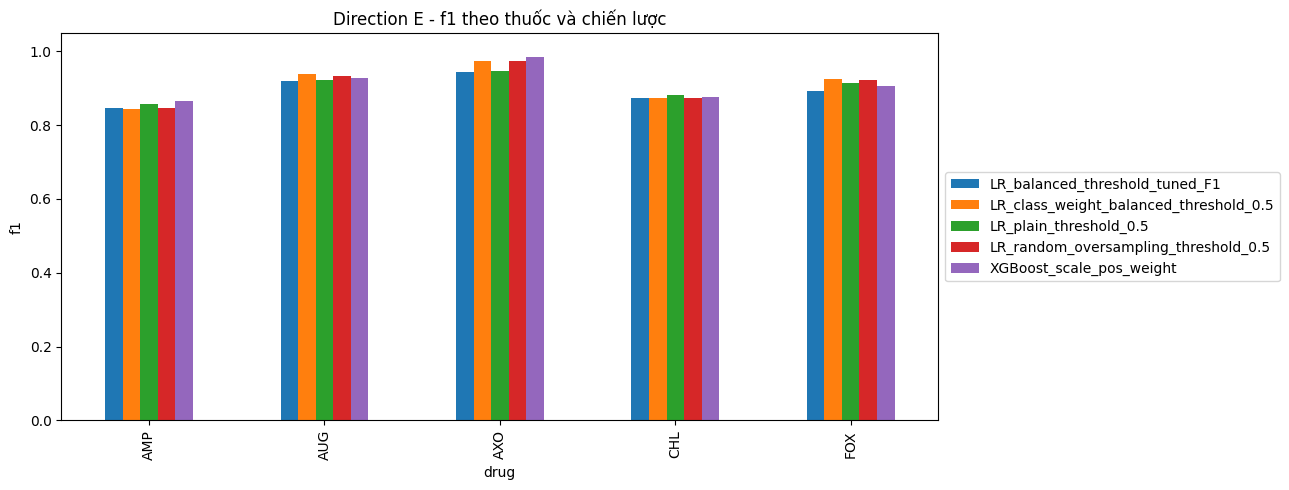

Saved: /content/salmonella_direction_E/outputs/direction_E_f1_by_strategy.png


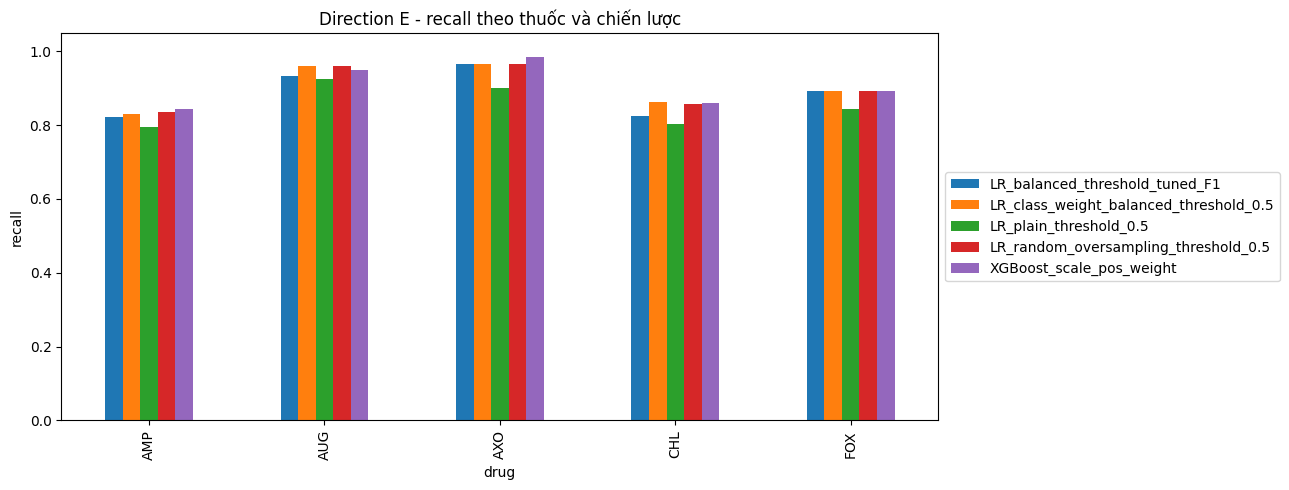

Saved: /content/salmonella_direction_E/outputs/direction_E_recall_by_strategy.png


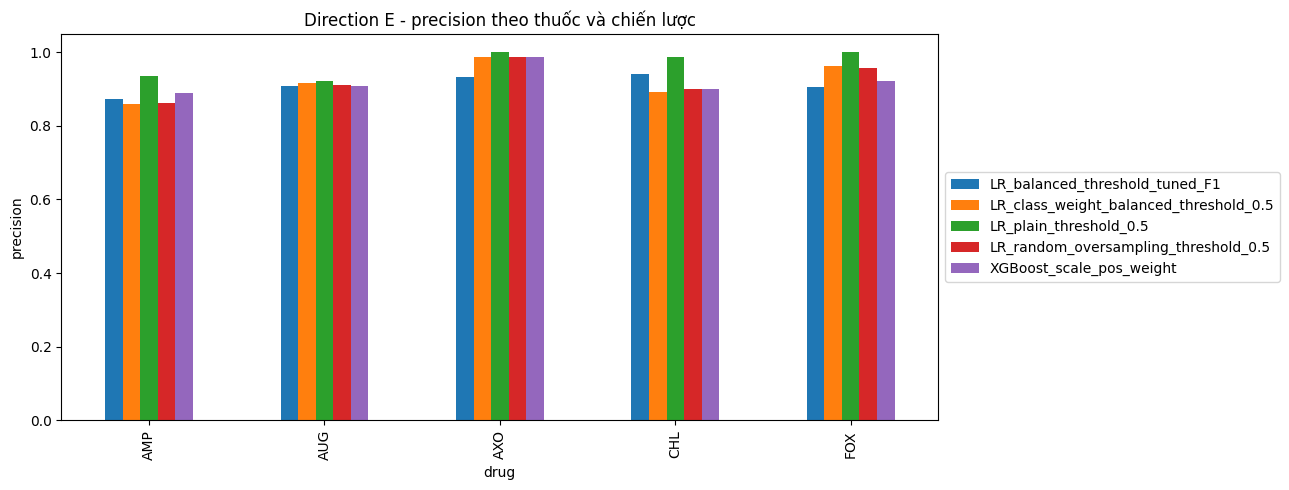

Saved: /content/salmonella_direction_E/outputs/direction_E_precision_by_strategy.png


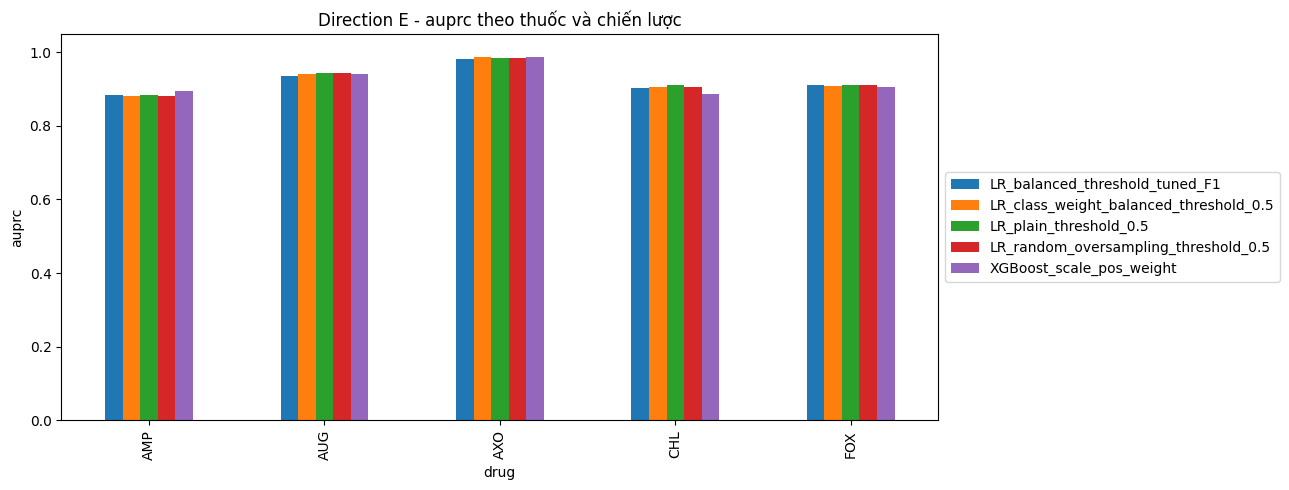

Saved: /content/salmonella_direction_E/outputs/direction_E_auprc_by_strategy.png


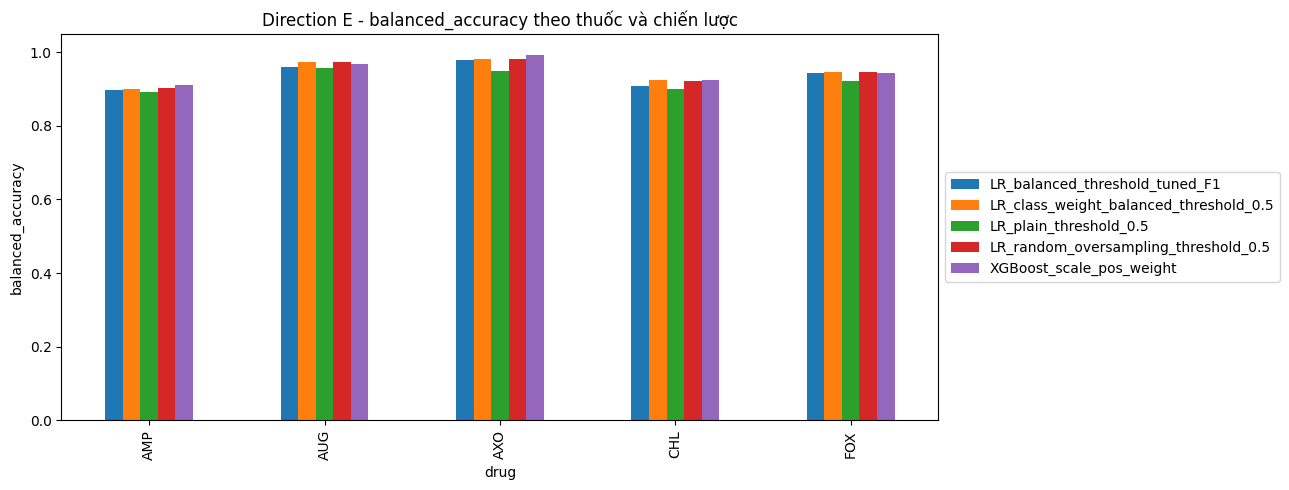

Saved: /content/salmonella_direction_E/outputs/direction_E_balanced_accuracy_by_strategy.png


In [13]:
# Vẽ biểu đồ F1 và recall theo chiến lược
for metric in ["f1", "recall", "precision", "auprc", "balanced_accuracy"]:
    pivot = summary_mean.pivot(index="drug", columns="strategy", values=metric)
    ax = pivot.plot(kind="bar", figsize=(13, 5))
    ax.set_title(f"Direction E - {metric} theo thuốc và chiến lược")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    fig_path = OUT_DIR / f"direction_E_{metric}_by_strategy.png"
    plt.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

In [14]:
# Phân tích trade-off precision/recall
tradeoff = summary_mean[["drug", "strategy", "precision", "recall", "f1", "balanced_accuracy", "auprc"]].copy()
tradeoff["recall_minus_precision"] = tradeoff["recall"] - tradeoff["precision"]
display(tradeoff.sort_values(["drug", "recall"], ascending=[True, False]))
tradeoff.to_csv(OUT_DIR / "direction_E_precision_recall_tradeoff.csv", index=False)

,drug,strategy,precision,recall,f1,balanced_accuracy,auprc,recall_minus_precision
4,AMP,XGBoost_scale_pos_weight,0.889302,0.845000,0.866058,0.911418,0.895171,-0.044302
3,AMP,LR_random_oversampling_threshold_0.5,0.861360,0.835000,0.847240,0.903325,0.880656,-0.026360
1,AMP,LR_class_weight_balanced_threshold_0.5,0.860016,0.830000,0.844079,0.900825,0.880975,-0.030016
0,AMP,LR_balanced_threshold_tuned_F1,0.874132,0.822500,0.846083,0.898621,0.882534,-0.051632
2,AMP,LR_plain_threshold_0.5,0.934292,0.795000,0.857937,0.891572,0.884809,-0.139292
6,AUG,LR_class_weight_balanced_threshold_0.5,0.915454,0.960714,0.937252,0.974289,0.940041,0.045260
8,AUG,LR_random_oversampling_threshold_0.5,0.909647,0.960714,0.934096,0.973804,0.942391,0.051067
9,AUG,XGBoost_scale_pos_weight,0.908722,0.950000,0.928467,0.968447,0.941711,0.041278
5,AUG,LR_balanced_threshold_tuned_F1,0.909231,0.932143,0.918817,0.959518,0.934439,0.022912
7,AUG,LR_plain_threshold_0.5,0.922356,0.925000,0.923063,0.957160,0.943754,0.002644


In [15]:
# Đặc trưng được chọn ổn định trong Direction E
stable_rows = []
for drug, counter in selected_by_drug.items():
    total_possible = N_REPEATS
    for feature, count in counter.most_common(30):
        stable_rows.append({
            "drug": drug,
            "feature": feature,
            "selected_count": count,
            "selected_frequency": count / total_possible,
        })

stable_df = pd.DataFrame(stable_rows)
display(stable_df.head(50))
stable_df.to_csv(OUT_DIR / "direction_E_top_stable_features.csv", index=False)

print("Tần suất lớn nhất:", stable_df["selected_frequency"].max())

,drug,feature,selected_count,selected_frequency
0,AMP,group_3068,10,1.0
1,AMP,CJW30_15375,10,1.0
2,AMP,HF382_002470,10,1.0
3,AMP,GXH02_05140,10,1.0
4,AMP,DSP25_11545,10,1.0
5,AMP,K1191_004890,10,1.0
6,AMP,FMQ12_17615,10,1.0
7,AMP,C3T99_20030,10,1.0
8,AMP,GSD89_003989,10,1.0
9,AMP,EE397_06365,10,1.0


Tần suất lớn nhất: 1.0


In [ ]:
# Kết luận
lines = []
lines.append("# Direction E - Kết luận tự động")
lines.append("")
lines.append("## Mục tiêu")
lines.append("Direction E kiểm tra các cách xử lý dữ liệu lệch lớp trong bài toán dự đoán kháng kháng sinh ở Salmonella.")
lines.append("Dữ liệu dùng là ma trận gen phụ đầy đủ; mỗi lần chia dữ liệu đều chọn 200 đặc trưng chỉ trên tập huấn luyện.")
lines.append("")

lines.append("## Thống kê nhãn")
for _, r in label_summary_df.iterrows():
    lines.append(f"- {r['drug']}: {int(r['n_samples'])} mẫu, {int(r['n_resistant'])} mẫu kháng ({r['resistant_rate']*100:.1f}%).")
lines.append("")

lines.append("## Chiến lược tốt nhất theo F1")
for _, r in best_f1_df.iterrows():
    lines.append(
        f"- {r['drug']}: {r['strategy']}, "
        f"F1={r['f1']:.3f}, recall={r['recall']:.3f}, precision={r['precision']:.3f}, "
        f"balanced accuracy={r['balanced_accuracy']:.3f}, AUPRC={r['auprc']:.3f}."
    )
lines.append("")

lines.append("## Diễn giải")
lines.append("- Nếu chiến lược có recall cao hơn nhưng precision thấp hơn, mô hình bắt được nhiều mẫu kháng hơn nhưng cũng báo nhầm nhiều hơn.")
lines.append("- Nếu chiến lược có F1 cao, đó là điểm cân bằng giữa precision và recall.")
lines.append("- Với dữ liệu lệch lớp, không nên chỉ nhìn accuracy thông thường; cần ưu tiên recall, F1, AUPRC và balanced accuracy.")
lines.append("")

lines.append("## Gợi ý sử dụng trong báo cáo")
lines.append("Direction E giúp bổ sung góc nhìn về nhóm mẫu kháng ít gặp. Nếu mục tiêu là giám sát kháng thuốc, có thể ưu tiên chiến lược tăng recall, nhưng cần kiểm soát số lượng cảnh báo giả thông qua precision và specificity.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUT_DIR / "AUTO_CONCLUSION_DIRECTION_E.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

# Direction E - Kết luận tự động

## Mục tiêu
Direction E kiểm tra các cách xử lý dữ liệu lệch lớp trong bài toán dự đoán kháng kháng sinh ở Salmonella.
Dữ liệu dùng là ma trận gen phụ đầy đủ; mỗi lần chia dữ liệu đều chọn 200 đặc trưng chỉ trên tập huấn luyện.

## Thống kê nhãn
- AMP: 1167 mẫu, 199 mẫu kháng (17.1%).
- AUG: 1167 mẫu, 139 mẫu kháng (11.9%).
- AXO: 1167 mẫu, 71 mẫu kháng (6.1%).
- CHL: 1167 mẫu, 126 mẫu kháng (10.8%).
- FOX: 1167 mẫu, 71 mẫu kháng (6.1%).

## Chiến lược tốt nhất theo F1
- AMP: XGBoost_scale_pos_weight, F1=0.866, recall=0.845, precision=0.889, balanced accuracy=0.911, AUPRC=0.895.
- AUG: LR_class_weight_balanced_threshold_0.5, F1=0.937, recall=0.961, precision=0.915, balanced accuracy=0.974, AUPRC=0.940.
- AXO: XGBoost_scale_pos_weight, F1=0.986, recall=0.986, precision=0.986, balanced accuracy=0.992, AUPRC=0.987.
- CHL: LR_plain_threshold_0.5, F1=0.882, recall=0.804, precision=0.987, balanced accuracy=0.901, AUPRC=0.910.
- FOX: LR_class_weight_balanced_

In [ ]:

import shutil
zip_path = shutil.make_archive(str(BASE_DIR / "salmonella_direction_E_outputs"), "zip", OUT_DIR)
print("Đã tạo file zip:", zip_path)
print("Nếu muốn tải về Colab, chạy:")
print("from google.colab import files")
print(f"files.download('{zip_path}')")

Đã tạo file zip: /content/salmonella_direction_E/salmonella_direction_E_outputs.zip
Nếu muốn tải về Colab, chạy:
from google.colab import files
files.download('/content/salmonella_direction_E/salmonella_direction_E_outputs.zip')
